In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df = pd.read_excel("BD_Mo.xlsx")

REVISION BASICA

In [96]:
df.head()

,ID_Empleado,Nombre,Apellido,Estado,Nacimiento,Genero,Departamento,Posicion,Nombre_Jefe,Evaluación,Sueldo
0,1404066949,Adeel,Osturnka,"California, Estados Unidos",1981-11-11,Hombre,Ingeniero Sistema,Ingeneiro II,Alex Sweetwater,9.14,91200
1,1012023185,Adell,Saada,"Texas, Estados Unidos",1991-07-23,Mujer,Ingeniero Sistema,Ingeneiro II,Alex Sweetwater,9.88,88650
2,1106026462,Adil,Sahoo,"California, Estados Unidos",1971-04-25,Hombre,Produccion,Tecnico II,Kelley Spirea,9.38,59400
3,1206038000,Alain,Robinson,"Texas, Estados Unidos",1979-06-30,Hombre,Produccion,Tecnico II,Amy Dunn,9.68,79200
4,1212052023,Alejandro,Bacong,"Texas, Estados Unidos",1993-06-30,Hombre,Tencologia Informacion,Ingeniero I,Peter Monroe,9.35,81500


In [97]:
df.loc[df['Departamento'] == "Executive Office", 'Departamento'] = "Oficina Ejecutiva"

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ID_Empleado   194 non-null    int64         
 1   Nombre        194 non-null    str           
 2   Apellido      194 non-null    str           
 3   Estado        194 non-null    str           
 4   Nacimiento    194 non-null    datetime64[us]
 5   Genero        194 non-null    str           
 6   Departamento  194 non-null    str           
 7   Posicion      194 non-null    str           
 8   Nombre_Jefe   194 non-null    str           
 9   Evaluación    194 non-null    float64       
 10  Sueldo        194 non-null    int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(7)
memory usage: 32.3 KB


In [99]:
df.shape

(194, 11)

In [100]:
df.columns

Index(['ID_Empleado', 'Nombre', 'Apellido', 'Estado', 'Nacimiento', 'Genero',
       'Departamento', 'Posicion', 'Nombre_Jefe', 'Evaluación', 'Sueldo'],
      dtype='str')

In [101]:
df.isna().sum()

ID_Empleado     0
Nombre          0
Apellido        0
Estado          0
Nacimiento      0
Genero          0
Departamento    0
Posicion        0
Nombre_Jefe     0
Evaluación      0
Sueldo          0
dtype: int64

TIPOS DE DATOS

In [102]:
df["Nacimiento"] = pd.to_datetime(df["Nacimiento"], errors="coerce")
df["Evaluación"] = pd.to_numeric(df["Evaluación"], errors="coerce")
df["Sueldo"] = pd.to_numeric(df["Sueldo"], errors="coerce")

PERFIL DEL PERSONAL

La matriz muestra el detalle por empleado (jefe, evaluación, sueldo y edad), permitiendo pasar del resumen a casos concretos y revisar qué empleados contribuyen a los resultados de cada departamento

In [103]:
df["Genero"].value_counts()

Genero
Mujer     108
Hombre     86
Name: count, dtype: int64

In [104]:
df["Departamento"].value_counts()

Departamento
Produccion                73
Tencologia Informacion    40
Administrador Office      35
Ventas                    20
Ingeniero Sistema         18
Oficina Ejecutiva          7
Ingeniero Sistema          1
Name: count, dtype: int64

In [105]:
df["Posicion"].value_counts()

Posicion
Ingeniero I          39
Tecnico II           33
Ingeneiro II         31
Tecnico I            30
Gerente              20
Administrativa I     15
Administracion II    14
Director             12
Name: count, dtype: int64

In [106]:
df["Estado"].value_counts()

Estado
Texas, Estados Unidos            77
California, Estados Unidos       53
Massachusetts, Estados Unidos    51
Colorado, Estados Unidos          1
Montana, Estados Unidos           1
Pennsylvania, Estados Unidos      1
Nueva York, Estados Unidos        1
Florida, Estados Unidos           1
Nevada, Estados Unidos            1
Virginia, Estados Unidos          1
North Dakota, Estados Unidos      1
Tennessee, Estados Unidos         1
Indiana, Estados Unidos           1
Idaho, Estados Unidos             1
Oregon, Estados Unidos            1
Ohio, Estados Unidos              1
Name: count, dtype: int64

DISTRIBUCION SALARIAL

In [107]:
#df["Sueldo"].describe()

In [108]:
#q1 = df["Sueldo"].quantile(0.25)
#q3 = df["Sueldo"].quantile(0.75)
#iqr = q3 - q1

In [109]:
#limite_inferior = q1 - 1.5 * iqr   
#limite_superior = q3 + 1.5 * iqr

In [110]:
#sueldo_atipicos = df[(df["Sueldo"] < limite_inferior) | (df["Sueldo"] > limite_superior)]
#sueldo_atipicos

In [111]:
df.groupby("Departamento")["Sueldo"].agg(["min","mean","median","max"])

,min,mean,median,max
Departamento,,,,
Administrador Office,36900,55850.428571,53333.0,99000
Ingeniero Sistema,75600,88731.111111,86850.0,102816
Ingeniero Sistema,115966,115966.000000,115966.0,115966
Oficina Ejecutiva,112500,124304.428571,122000.0,144000
Produccion,26536,61737.506849,62000.0,123564
Tencologia Informacion,46800,81796.625000,77250.0,124561
Ventas,81000,108962.600000,113333.0,129600


EVALUACION DEL RENDIMIENTO

In [112]:
df.groupby("Departamento")["Evaluación"].mean().sort_values(ascending=False)

Departamento
Administrador Office      8.270000
Oficina Ejecutiva         8.047143
Produccion                7.653973
Ingeniero Sistema         7.600000
Ingeniero Sistema         7.340556
Tencologia Informacion    7.129000
Ventas                    6.885500
Name: Evaluación, dtype: float64

In [113]:
df.groupby("Posicion")["Evaluación"].mean().sort_values(ascending=False)

Posicion
Administrativa I     8.488667
Administracion II    8.126429
Tecnico II           7.961818
Director             7.514167
Gerente              7.448500
Tecnico I            7.358000
Ingeneiro II         7.341935
Ingeniero I          7.071795
Name: Evaluación, dtype: float64

In [114]:
df.groupby("Nombre_Jefe")["Evaluación"].mean().sort_values(ascending=False)

Nombre_Jefe
Kelley Spirea         8.541250
David Stanley         8.470000
Brandon R. LeBlanc    8.442222
Elijiah Gray          8.421818
Board of Directors    8.047143
Kissy Sullivan        7.923333
Debra Houlihan        7.895000
Michael Albert        7.870000
Amy Dunn              7.506842
Simon Roup            7.444118
Alex Sweetwater       7.340556
Lynn Daneault         7.301250
Jennifer Zamora       7.178571
Webster Butler        7.113333
Brannon Miller        7.076316
Eric Dougall          7.062500
Peter Monroe          7.031429
Janet King            6.867500
John Smith            6.624444
Name: Evaluación, dtype: float64

Las tablas resumen agregan métricas clave (empleados, sueldo total, sueldo promedio, evaluación media) por departamento, lo que facilita comparar áreas y entender su peso dentro de la organización

RELACION SUELDO - EVALUACION

In [115]:
df[["Sueldo","Evaluación"]].corr()

,Sueldo,Evaluación
Sueldo,1.000000,-0.126093
Evaluación,-0.126093,1.000000


ESTRUCTURA JERARQUICA

In [116]:
df.groupby("Nombre_Jefe")["ID_Empleado"].count().sort_values(ascending=False)

Nombre_Jefe
Elijiah Gray          22
Brannon Miller        19
Amy Dunn              19
Alex Sweetwater       18
Simon Roup            17
Peter Monroe          14
Janet King            12
John Smith             9
Brandon R. LeBlanc     9
David Stanley          8
Kelley Spirea          8
Lynn Daneault          8
Jennifer Zamora        7
Board of Directors     7
Debra Houlihan         4
Eric Dougall           4
Kissy Sullivan         3
Michael Albert         3
Webster Butler         3
Name: ID_Empleado, dtype: int64

ANALISIS DEMOGRAFICO

In [117]:
df["Anio_Nacimiento"] = df["Nacimiento"].dt.year
df["Edad_aprox"] = 2026 - df["Anio_Nacimiento"]

In [118]:
df["Anio_Nacimiento"].value_counts().sort_index()
df.groupby("Genero")["Edad_aprox"].agg(["count","mean","median"])

,count,mean,median
Genero,,,
Hombre,86,46.593023,46.0
Mujer,108,45.314815,43.0


Las tablas de agrupación de edad muestran cuántos empleados pertenecen a cada rango y cómo se distribuyen por género y departamento, apoyando análisis demográficos simples

GRAFICOS

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9064\2001772764.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Genero", palette="Blues_r")


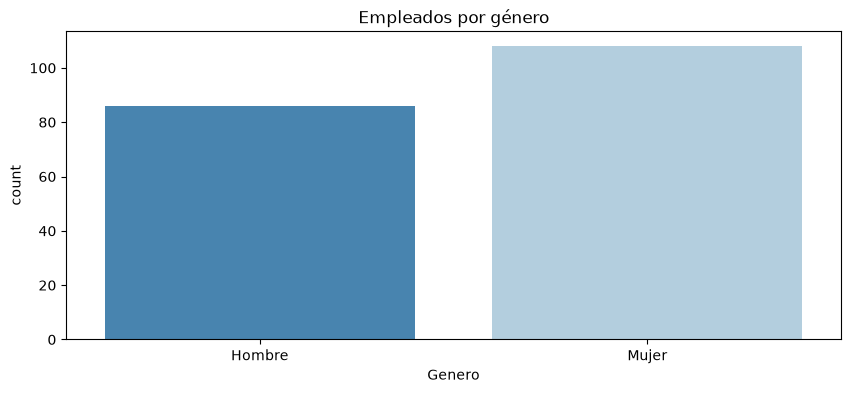

In [89]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="Genero", palette="Blues_r")
plt.title("Empleados por género")
plt.show()

El gráfico de barras muestra el número de empleados por género. La comparación de estos conteos permite evaluar el grado de equilibrio en la plantilla y sirve como punto de partida para analizar diversidad y posibles sesgos en contratación o promoción.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9064\876040200.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Departamento", palette="Set1")


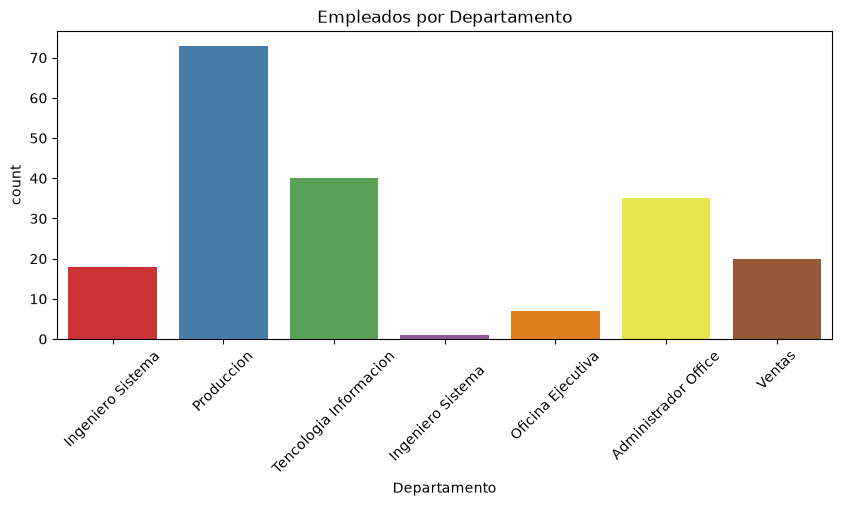

In [90]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="Departamento", palette="Set1")
plt.xticks(rotation=45)
plt.title("Empleados por Departamento")
plt.show()

Este gráfico presenta la frecuencia de empleados por departamento. Observar qué áreas concentran más personal ayuda a identificar dónde se acumula capacidad operativa, posibles sobrecargas de trabajo y departamentos que podrían requerir refuerzo de recursos humanos.

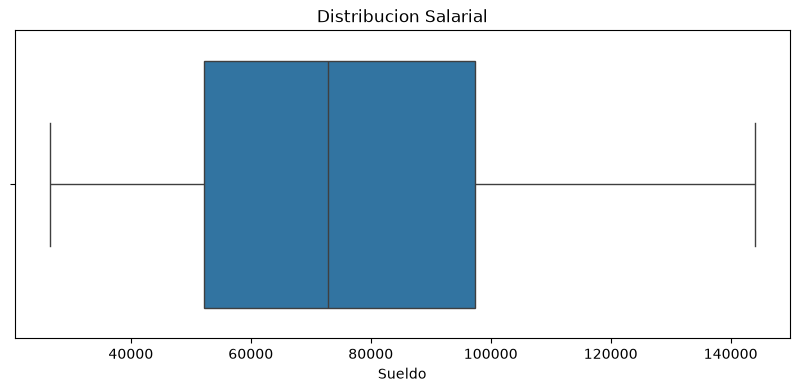

In [91]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Sueldo")
plt.title("Distribucion Salarial")
plt.show()

El boxplot resume la distribución de sueldos mediante mediana, cuartiles y valores extremos. El rango intercuartílico (IQR) recoge el 50% central de la población salarial, mientras que los bigotes y posibles valores atípicos ilustran la dispersión y la presencia de sueldos significativamente altos o bajos respecto al resto de la plantilla.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9064\2948159002.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Departamento", y="Evaluación", estimator=np.mean, palette="Set2")


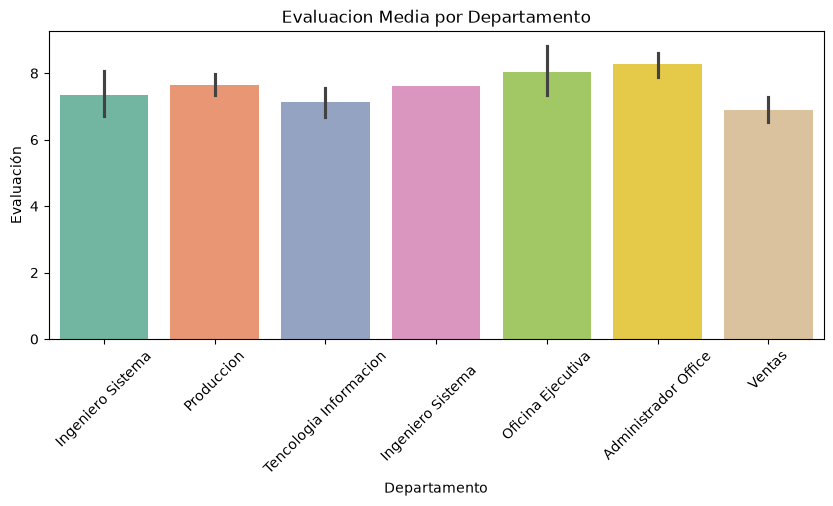

In [92]:
plt.figure(figsize=(10,4))
sns.barplot(data=df, x="Departamento", y="Evaluación", estimator=np.mean, palette="Set2")
plt.xticks(rotation=45)
plt.title("Evaluacion Media por Departamento")
plt.show()

La barra de evaluación media por departamento utiliza la media aritmética de la evaluación de desempeño dentro de cada área. Comparar estos promedios permite detectar diferencias sistemáticas entre departamentos y priorizar acciones de mejora en aquellos con niveles de desempeño relativamente inferiores.

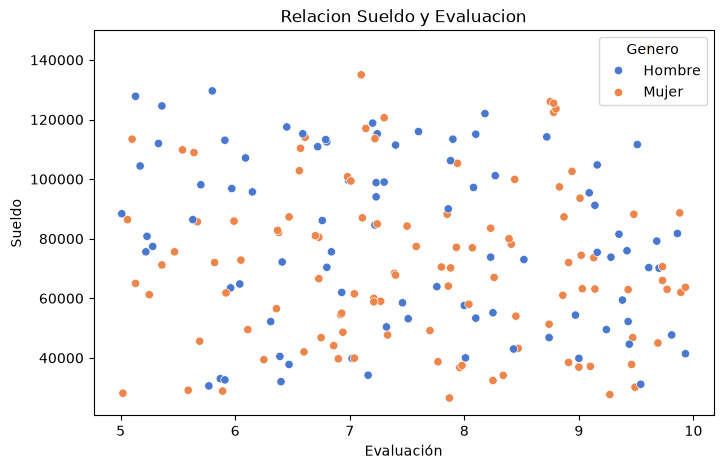

In [93]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Evaluación", y="Sueldo", hue="Genero", palette="muted")
plt.title("Relacion Sueldo y Evaluacion")
plt.show()

El diagrama de dispersión representa cada empleado en el plano sueldo–evaluación, diferenciando el género mediante color. La nube de puntos permite detectar patrones visuales entre remuneración y desempeño; adicionalmente, el coeficiente de correlación entre ambas variables cuantifica el grado de asociación lineal y ayuda a identificar incoherencias en la política salarial.